# Test of Time-independent Unitary Dynamics

The purpose of this notebook is to test and visually verify the correct implementation of unitary dynamics with time-independent Hamiltonian. We look at two qubits, evolving under a flip-flop coupling.

## 1. Imports

In [4]:
from qsim.dynamics import HamiltonianGenerator, ExponentialPropagator, Dynamics, DiagonalPropagator
from qsim.logging import Logger
from qsim.lin_alg import I, sigmaZ, sigmaX
from qsim.state import Detector, DensityMatrix, Ket
from tqdm.auto import tqdm
import numpy as np

import math
import matplotlib.pyplot as plt

## 2. Configure Dynamics

In [5]:
# System dimension
d = 4

In [6]:
H = sigmaX.tensor(sigmaX)

In [7]:
def warnIfIllegitimate(state, t):
    if not state.isNormalised():
        print(f'Illegitimate State at t={t}')

In [8]:
generator = HamiltonianGenerator(H=H)
propagator = ExponentialPropagator(callbacks=None)

In [9]:
dynamics = Dynamics(propagator, generator)

## 3. Logger Setup

In [10]:
detector_qubit1 = Detector(sigmaZ, dims=(2,2), target_sites=(0,))
detector_qubit2 = Detector(sigmaZ, dims=(2,2), target_sites=(1,))

detector_joint = Detector(sigmaZ.tensor(sigmaZ))

In [11]:
logger_composite = Logger([detector_qubit1, detector_qubit2, detector_joint])
dynamics.addCallback(logger_composite.log)

## 4. Evolution

In [12]:
initial_state = DensityMatrix(np.array([[0,0,0,0],[0,1,0,0],[0,0,0,0],[0,0,0,0]]))
#initial_state = Ket(np.array([0,1,0,0]))

In [13]:
ts = np.linspace(0,15,300)

In [14]:
dynamics.evolve(initial_state, ts=list(ts))

DensityMatrix(dim=4)

## 5. Visualisation

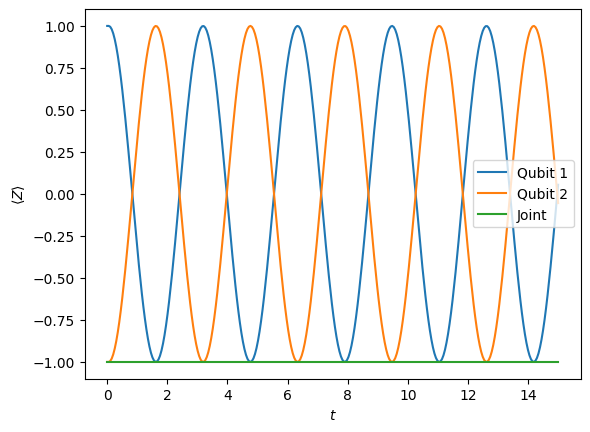

In [15]:
plt.plot(ts, logger_composite.observable_log[detector_qubit1].values(), label='Qubit 1')
plt.plot(ts, logger_composite.observable_log[detector_qubit2].values(), label = 'Qubit 2')
plt.plot(ts, logger_composite.observable_log[detector_joint].values(), label = 'Joint')
plt.ylabel(r'$\langle Z \rangle$')
plt.xlabel('$t$')
plt.legend()

## 6. Heisenberg Evolution

In [16]:
generator = HamiltonianGenerator(H=H)
propagator = ExponentialPropagator()

In [17]:
heisenberg_dynamics = Dynamics(propagator, generator)

In [18]:
reduced_ts = ts
ops1 = [heisenberg_dynamics.evolveOperator(sigmaZ.tensor(I(2)), ts=[0], t0=t) for t in tqdm(reduced_ts)]
ops2 = [heisenberg_dynamics.evolveOperator(I(2).tensor(sigmaZ), ts=[0], t0=t) for t in tqdm(reduced_ts)]

100%|██████████| 300/300 [00:00<00:00, 72025.83it/s]


In [19]:


initial_state = DensityMatrix(np.array([[0,0,0,0],[0,1,0,0],[0,0,0,0],[0,0,0,0]]))


/Users/matthewmackinnon/Documents/repos/QSim/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/matthewmackinnon/Documents/repos/QSim/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


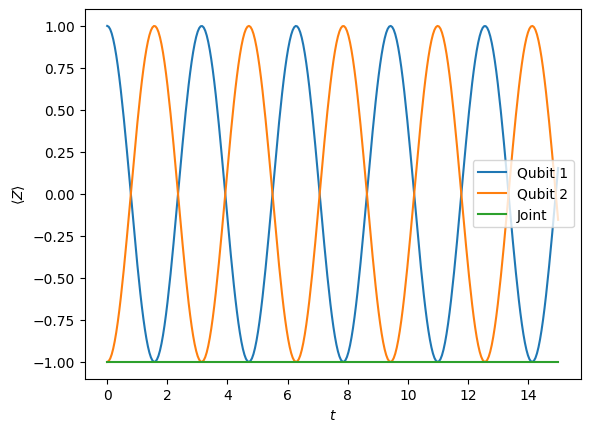

In [20]:
plt.plot(reduced_ts, [(op @ initial_state).trace() for op in ops1], label='Qubit 1')
plt.plot(reduced_ts, [(op @ initial_state).trace() for op in ops2], label='Qubit 2')
plt.plot(ts, logger_composite.observable_log[detector_joint].values(), label = 'Joint')
plt.ylabel(r'$\langle Z \rangle$')
plt.xlabel('$t$')
plt.legend()

## 7. Diagonalised Evolution

In [21]:
H = sigmaX.tensor(sigmaX)
new_basis = H.eigenvectors
H = H.changeBasis(new_basis)

In [22]:
generator = HamiltonianGenerator(H=H)
propagator = DiagonalPropagator(callbacks=None)

In [23]:
dynamics = Dynamics(propagator, generator)

In [24]:
detector_qubit1 = Detector((sigmaZ ^ I(2)).changeBasis(new_basis))
detector_qubit2 = Detector((I(2) ^ sigmaZ).changeBasis(new_basis))

detector_joint = Detector((sigmaZ ^ sigmaZ).changeBasis(new_basis))

In [25]:
logger_composite = Logger([detector_qubit1, detector_qubit2, detector_joint])
dynamics.addCallback(logger_composite.log)

In [26]:
initial_state = DensityMatrix(np.array([[0,0,0,0],[0,1,0,0],[0,0,0,0],[0,0,0,0]])).changeBasis(new_basis)
#initial_state = Ket(np.array([0,1,0,0]))

In [27]:
dynamics.evolve(initial_state, ts=list(ts))

DensityMatrix(dim=4)

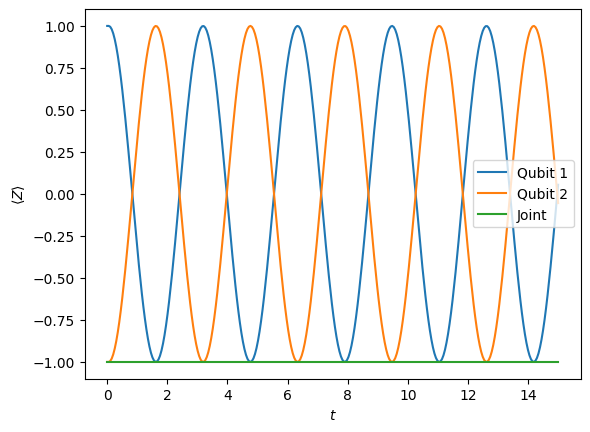

In [28]:
plt.plot(ts, logger_composite.observable_log[detector_qubit1].values(), label='Qubit 1')
plt.plot(ts, logger_composite.observable_log[detector_qubit2].values(), label = 'Qubit 2')
plt.plot(ts, logger_composite.observable_log[detector_joint].values(), label = 'Joint')
plt.ylabel(r'$\langle Z \rangle$')
plt.xlabel('$t$')
plt.legend()